# Bimodal Gaussian location model

We simulate **bimodal** data from a two-component Gaussian mixture, then fit a **unimodal** normal-location model with `sample_pro`. Under misspecification, the PrO posterior predictive for $y$ should place mass near both mixture modes.

In [1]:
import numpy as np
import pymc as pm
import matplotlib.pyplot as plt

from pymc_prop import sample_pro

FIGSIZE = (6.5, 4.0)
COLOR_DATA = "#FF0000"
COLOR_DATA_OVERLAY = "0.6"
COLOR_PRO = "#bca0ff"


## Simulate bimodal data

$0.4\,\mathcal{N}(-1.5,\,0.7^2) + 0.6\,\mathcal{N}(2.25,\,0.7^2)$.


In [2]:
N = 800
sigma = 0.7
component_means = np.array([-1.5, 2.25])
component_weights = np.array([0.4, 0.6])
SEED = 2026

# draw component labels then observations -- reproducible rng
rng = np.random.default_rng(SEED)
components = rng.choice(len(component_means), size=N, p=component_weights)
y = rng.normal(loc=component_means[components], scale=sigma)

# plotting limits around component means
xlim = (component_means.min() - 3 * sigma, component_means.max() + 3 * sigma)


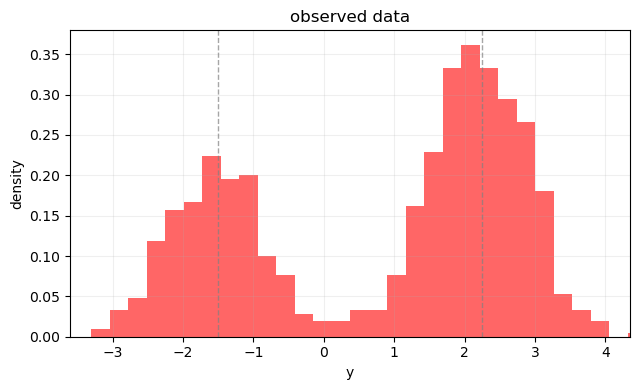

In [3]:
# histogram of the simulated data (verify bimodality)
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.hist(y, bins=30, density=True, color=COLOR_DATA, alpha=0.6)
# mark true component means used to generate the data
for mu in component_means:
    ax.axvline(mu, color="0.5", linestyle="--", linewidth=1, alpha=0.7)
ax.set(title="observed data", xlabel="y", ylabel="density", xlim=xlim)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## PyMC model (misspecified unimodal likelihood)

We fit $y_i \sim \mathcal{N}(\mu, \sigma^2)$ with known $\sigma$ and $\mu \sim \mathcal{N}(0, 1)$.


In [ ]:
# define a misspecified unimodal normal-location model
# fit N(mu, sigma^2) with known sigma; prior N(0,1) on mu
with pm.Model() as model:
    mu = pm.Normal("mu", mu=0.0, sigma=1.0)
    pm.Normal("y", mu=mu, sigma=sigma, observed=y)


## Sample with `sample_pro`

Every EM step is kept for trajectory plots.


In [5]:
# run the PrO sampler and  keep full trajectory for plotting;
# final_particles used for predictive draws
result = sample_pro(
    model=model,
    n_particles=40,
    n_steps=2500,
    burn_in=0,
    thinning=1,
    step_size=8e-4,
    learning_rate=800.0,
    random_seed=SEED,
)

traj = result.particles
# take final step's mu values
final_particles = traj[-1, :, 0]
print("traj shape (n_steps, n_particles, n_params):", traj.shape)

traj shape (n_steps, n_particles, n_params): (2500, 40, 1)


## Plots

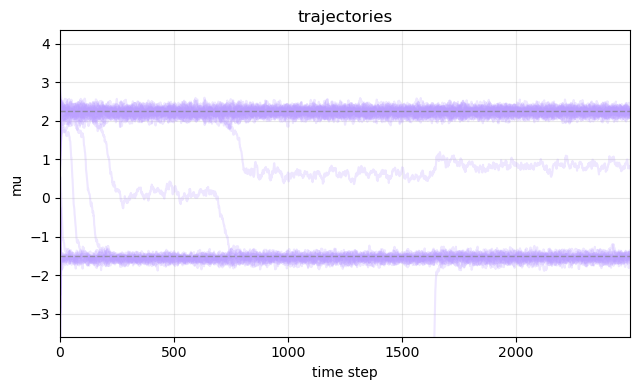

In [6]:
def kde_1d(samples, grid, bw=0.35):
    samples = np.asarray(samples).reshape(-1, 1)
    grid = np.asarray(grid).reshape(1, -1)
    u = (grid - samples) / bw
    kern = np.exp(-0.5 * u ** 2) / (np.sqrt(2.0 * np.pi) * bw)
    return np.mean(kern, axis=0)


fig, ax = plt.subplots(figsize=FIGSIZE)
steps = np.arange(traj.shape[0])
for j in range(traj.shape[1]):
    # plot each particle's path through parameter space
    ax.plot(steps, traj[:, j, 0], color=COLOR_PRO, alpha=0.25)
# show true component means for reference
for mu in component_means:
    ax.axhline(mu, color="0.5", linestyle="--", linewidth=1, alpha=0.7)
ax.set(
    title="trajectories",
    xlabel="time step",
    ylabel="mu",
    xlim=(0, steps[-1]),
    ylim=xlim,
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Data vs PrO posterior predictive

For each final particle $\mu_j$, draw $y^{\mathrm{rep}} \sim \mathcal{N}(\mu_j, \sigma^2)$ (known $\sigma$). The purple curve is a KDE of those posterior predictive draws in $y$-space.

If PrO is working, predictive mass should sit near **both** mixture component means.

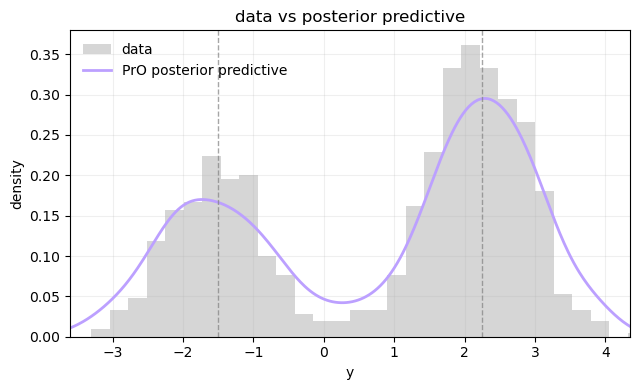

In [7]:
# build posterior predictive draws from final PrO particles
# repeat final mu particles to generate y_rep ~ N(mu_j, sigma^2)
n_rep = max(1, N // final_particles.shape[0])
rng_pp = np.random.default_rng(SEED + 1)
y_pp = rng_pp.normal(
    loc=np.repeat(final_particles, n_rep),
    scale=sigma,
)

fig, ax = plt.subplots(figsize=FIGSIZE)
grid = np.linspace(xlim[0], xlim[1], 400)

# overlay data histogram and PrO posterior predictive KDE
ax.hist(y, bins=30, density=True, alpha=0.4, color=COLOR_DATA_OVERLAY, label="data")
ax.plot(
    grid,
    kde_1d(y_pp, grid, bw=0.35),
    color=COLOR_PRO,
    lw=2,
    label="PrO posterior predictive",
)
for mu in component_means:
    ax.axvline(mu, color="0.5", linestyle="--", linewidth=1, alpha=0.7)

ax.set(title="data vs posterior predictive", xlabel="y", ylabel="density", xlim=xlim)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()
